[OK] Local Jupyter — no Kaggle auth needed
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
[OK] TensorFlow: 2.15.0
[OK] GPU: []
[OK] Mixed precision policy: <Policy "float32">

PART 1: CLINICAL (TABULAR) MODEL
Dataset shape: (303, 14)
target
0    164
1    139
Name: count, dtype: int64
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 64)                896       
                                                                 
 batch_normalization_2 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 64)                0         
                                                                 
 dense_13 (Dense)            (None, 32)                2

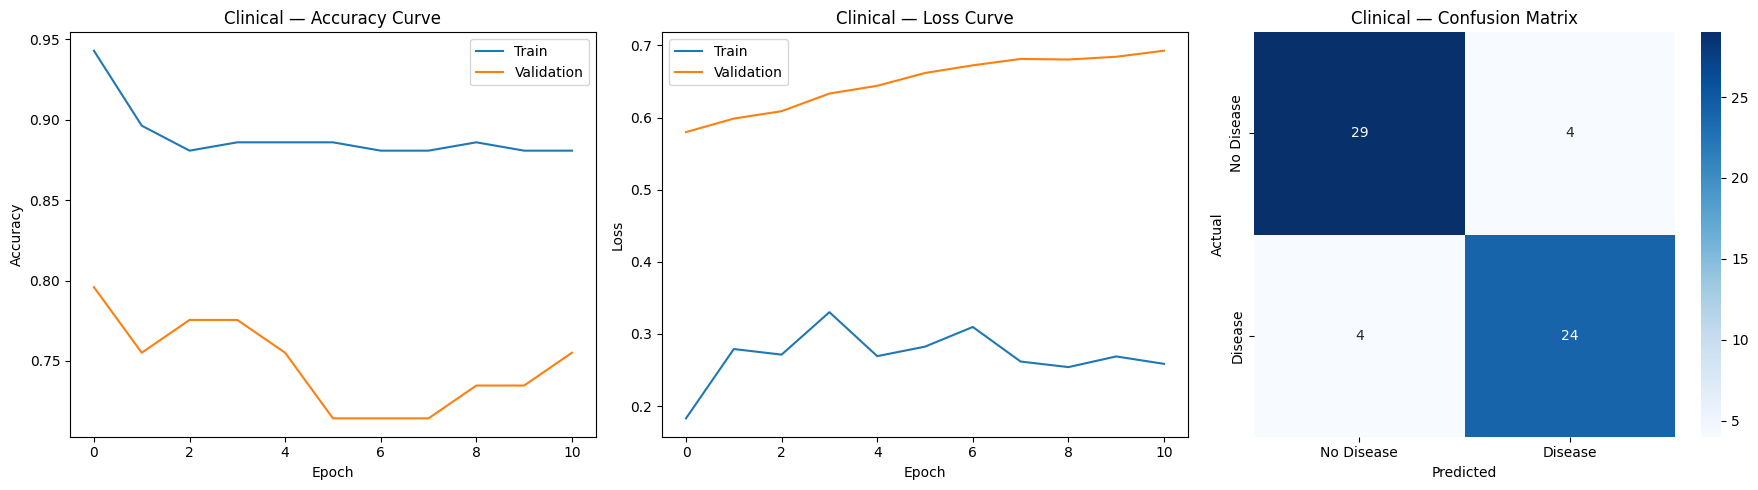

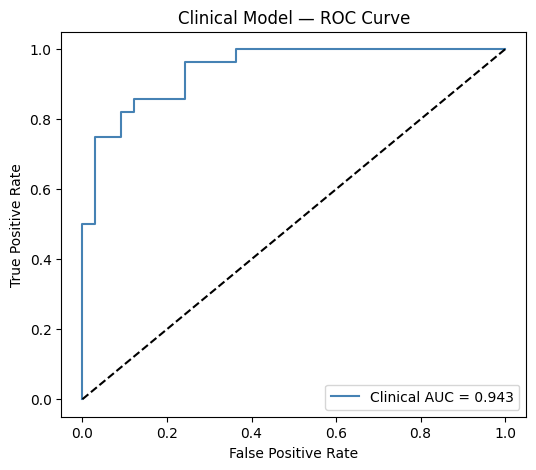


PART 2: ECG IMAGE MODEL (EfficientNetB0) — FIXED
[OK] ECG dataset path: E:\Zafrin Kaisar\archive (1)\ECG_Image_data
Train: E:\Zafrin Kaisar\archive (1)\ECG_Image_data\train
Test : E:\Zafrin Kaisar\archive (1)\ECG_Image_data\test
Sampled E:\Zafrin Kaisar\archive (1)\ECG_Image_data\train → C:\Users\USER\AppData\Local\Temp\ecg_sampled\train
Sampled E:\Zafrin Kaisar\archive (1)\ECG_Image_data\test → C:\Users\USER\AppData\Local\Temp\ecg_sampled\test
Found 14865 images belonging to 6 classes.
Found 8873 images belonging to 6 classes.
ECG Classes: ['F', 'M', 'N', 'Q', 'S', 'V']
Normal class index: 2 (N)
Class weights: {0: 3.8590342679127727, 1: 0.8258333333333333, 2: 0.8258333333333333, 3: 0.8258333333333333, 4: 1.114484930274404, 5: 0.8258333333333333}
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                           

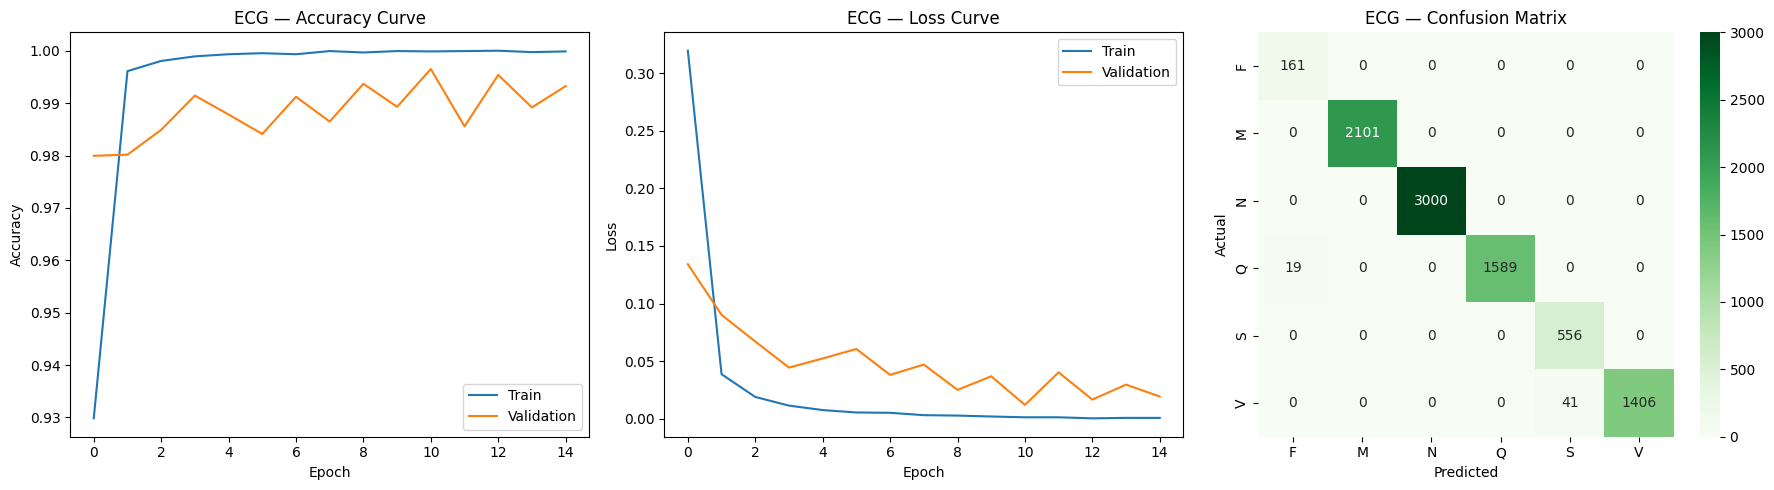

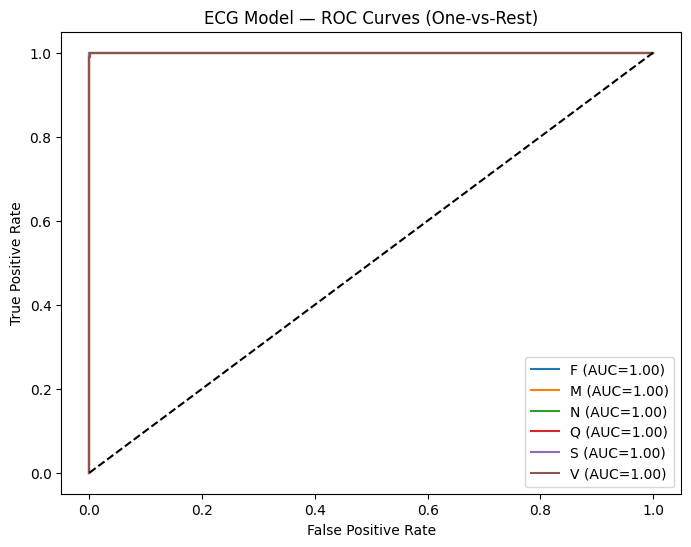

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "C:\Users\USER\anaconda3\envs\heartdisease\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USER\anaconda3\envs\heartdisease\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\USER\anaconda3\envs\heartdisease\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "C:\Users\USER\anaconda3\envs\heartdisease\lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\USER\anaconda3\envs\heartdisease\lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'


PART 3: LATE FUSION (MULTIMODAL)

[RESULTS] FUSION RESULT:
  Clinical Probability (disease): 0.2679
  ECG Abnormal Probability: 1.0
  ECG Class Breakdown: {'F': 1.0, 'M': 0.0, 'N': 0.0, 'Q': 0.0, 'S': 0.0, 'V': 0.0}
  Fusion Probability: 0.7072
  Final Prediction: [HEART]  Heart Disease Detected

[OK] ALL DONE — Files saved:
  clinical_model_final.keras
  ecg_model_final.keras
  clinical_preprocessing.pkl
  fusion_config.pkl
  clinical_results.png  |  clinical_roc.png
  ecg_results.png       |  ecg_roc.png

[RESULTS] Summary:
  Clinical  — Acc: 0.869 | F1: 0.857 | AUC: 0.943
  ECG       — Acc: 0.993 | F1: 0.993
  Fusion    — weights Clinical:0.4 | ECG:0.6


In [3]:
# ==============================================================
# MULTIMODAL HEART DISEASE PREDICTION — FULL PRODUCTION SCRIPT
# Clinical CSV + ECG Images → EfficientNetB0 → Late Fusion
# LOCAL JUPYTER NOTEBOOK VERSION — FIXED (no more NaN loss)
# ==============================================================
# [OK] EfficientNetB0 (VGG16 er bodole — faster, more accurate)
# [OK] Automatic Dataset Sampling (3000 per class) — now filters to real image files only
# [OK] NO Mixed Precision (this was a NaN source — explicitly forced OFF below)
# [OK] Checkpoint + Resume Training
# [OK] Learning Rate Scheduler (ReduceLROnPlateau) + safe base LR
# [OK] Gradient Clipping (clipnorm) — prevents exploding gradients -> NaN
# [OK] TerminateOnNaN — a bad run stops immediately instead of wasting hours
# [OK] Class-weighted training (dataset is imbalanced: N=3000 vs F=161 etc.)
# [OK] No horizontal flip on ECG images (flipping destroys waveform meaning)
# [OK] TensorBoard Logging
# [OK] ROC Curve + AUC
# [OK] Confusion Matrix
# [OK] Precision, Recall, F1-Score, Accuracy
# [OK] Loss Curve + Accuracy Curve
# [OK] Clinical + ECG Weighted Fusion — now NaN-safe, refuses to silently say "Healthy"
# [OK] Final Inference Function
# ==============================================================
# ==============================================================
# WHAT WAS FIXED vs the version that produced loss=nan (read this once):
#
# 1. LEARNING RATE — Adam(1e-3) is too aggressive for training a dense head
#    on top of a frozen EfficientNetB0. Changed to Adam(1e-4).
# 2. GRADIENT CLIPPING — added clipnorm=1.0 to the ECG optimizer so a single
#    bad batch can't blow up the weights into NaN.
# 3. TerminateOnNaN — added so if NaN ever reappears, training halts at that
#    epoch instead of burning 5+ hours of GPU/CPU time producing garbage.
# 4. CORRUPT / NON-IMAGE FILES — sample_directory() previously copied "*.*"
#    which can include non-image files (Thumbs.db, .ini, etc.) alongside
#    images. A single unreadable file fed into the generator can silently
#    produce garbage tensors -> NaN loss. Now filtered to real image
#    extensions only.
# 5. HORIZONTAL FLIP — was True. ECG waveforms are directionally meaningful
#    (a flipped QRS complex is not a valid ECG); this doesn't cause NaN but
#    it does corrupt the label semantics, so it's turned off.
# 6. CLASS WEIGHTS — dataset is heavily imbalanced (N=3000, F=161). Without
#    weighting, the model can collapse to predicting the majority class only,
#    which combined with a high LR increases NaN risk. Added balanced
#    class weights.
# 7. NaN-SAFE FUSION — predict_fusion() now raises a clear error if the ECG
#    model returns NaN, instead of silently defaulting to "Healthy".
# ==============================================================

# ECG IMAGE DATASET PATH (tomar PC-er actual path):
ECG_DATA_PATH = r"E:\Zafrin Kaisar\archive (1)\ECG_Image_data"
# ==============================================================

import os
print("[OK] Local Jupyter — no Kaggle auth needed")

# ---- TensorBoard ----
%load_ext tensorboard

# ---- Embedded Clinical CSV ----
import io
CLINICAL_CSV_TEXT = """age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
62,0,3,140,268,0,2,160,0,3.6,2,2,1,1
57,0,3,120,354,0,0,163,1,0.6,0,0,1,0
63,1,3,130,254,0,2,147,0,1.4,1,1,3,1
53,1,3,140,203,1,2,155,1,3.1,2,0,3,1
57,1,3,140,192,0,0,148,0,0.4,1,0,2,0
56,0,1,140,294,0,2,153,0,1.3,1,0,1,0
56,1,2,130,256,1,2,142,1,0.6,1,1,2,1
44,1,1,120,263,0,0,173,0,0,0,0,3,0
52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
57,1,2,150,168,0,0,174,0,1.6,0,0,1,0
48,1,1,110,229,0,0,168,0,1,2,0,3,1
54,1,3,140,239,0,0,160,0,1.2,0,0,1,0
48,0,2,130,275,0,0,139,0,0.2,0,0,1,0
49,1,1,130,266,0,0,171,0,0.6,0,0,1,0
64,1,0,110,211,0,2,144,1,1.8,1,0,1,0
58,0,0,150,283,1,2,162,0,1,0,0,1,0
58,1,1,120,284,0,2,160,0,1.8,1,0,1,1
58,1,2,132,224,0,2,173,0,3.2,0,2,3,1
60,1,3,130,206,0,2,132,1,2.4,1,2,3,1
50,0,2,120,219,0,0,158,0,1.6,1,0,1,0
58,0,2,120,340,0,0,172,0,0,0,0,1,0
66,0,0,150,226,0,0,114,0,2.6,2,0,1,0
43,1,3,150,247,0,0,171,0,1.5,0,0,1,0
40,1,3,110,167,0,2,114,1,2,1,0,3,1
69,0,0,140,239,0,0,151,0,1.8,0,2,1,0
60,1,3,117,230,1,0,160,1,1.4,0,2,3,1
64,1,2,140,335,0,0,158,0,0,0,0,1,1
59,1,3,135,234,0,0,161,0,0.5,1,0,3,0
44,1,2,130,233,0,0,179,1,0.4,0,0,1,0
42,1,3,140,226,0,0,178,0,0,0,0,1,0
43,1,3,120,177,0,2,120,1,2.5,1,0,3,1
57,1,3,150,276,0,2,112,1,0.6,1,1,2,1
55,1,3,132,353,0,0,132,1,1.2,1,1,3,1
61,1,2,150,243,1,0,137,1,1,1,0,1,0
65,0,3,150,225,0,2,114,0,1,1,3,3,1
40,1,0,140,199,0,0,178,1,1.4,0,0,3,0
71,0,1,160,302,0,0,162,0,0.4,0,2,1,0
59,1,2,150,212,1,0,157,0,1.6,0,0,1,0
61,0,3,130,330,0,2,169,0,0,0,0,1,1
58,1,2,112,230,0,2,165,0,2.5,1,1,3,1
51,1,2,110,175,0,0,123,0,0.6,0,0,1,0
50,1,3,150,243,0,2,128,0,2.6,1,0,3,1
65,0,2,140,417,1,2,157,0,0.8,0,1,1,0
53,1,2,130,197,1,2,152,0,1.2,2,0,1,0
41,0,1,105,198,0,0,168,0,0,0,1,1,0
65,1,3,120,177,0,0,140,0,0.4,0,0,3,0
44,1,3,112,290,0,2,153,0,0,0,1,1,1
44,1,1,130,219,0,2,188,0,0,0,0,1,0
60,1,3,130,253,0,0,144,1,1.4,0,1,3,1
54,1,3,124,266,0,2,109,1,2.2,1,1,3,1
50,1,2,140,233,0,0,163,0,0.6,1,1,3,1
41,1,3,110,172,0,2,158,0,0,0,0,3,1
54,1,2,125,273,0,2,152,0,0.5,2,1,1,0
51,1,0,125,213,0,2,125,1,1.4,0,1,1,0
51,0,3,130,305,0,0,142,1,1.2,1,0,3,1
46,0,2,142,177,0,2,160,1,1.4,2,0,1,0
58,1,3,128,216,0,2,131,1,2.2,1,3,3,1
54,0,2,135,304,1,0,170,0,0,0,0,1,0
54,1,3,120,188,0,0,113,0,1.4,1,1,3,1
60,1,3,145,282,0,2,142,1,2.8,1,2,3,1
60,1,2,140,185,0,2,155,0,3,1,0,1,1
54,1,2,150,232,0,2,165,0,1.6,0,0,3,0
59,1,3,170,326,0,2,140,1,3.4,2,0,3,1
46,1,2,150,231,0,0,147,0,3.6,1,0,1,1
65,0,2,155,269,0,0,148,0,0.8,0,0,1,0
67,1,3,125,254,1,0,163,0,0.2,1,2,3,1
62,1,3,120,267,0,0,99,1,1.8,1,2,3,1
65,1,3,110,248,0,2,158,0,0.6,0,2,2,1
44,1,3,110,197,0,2,177,0,0,0,1,1,1
65,0,2,160,360,0,2,151,0,0.8,0,0,1,0
60,1,3,125,258,0,2,141,1,2.8,1,1,3,1
51,0,2,140,308,0,2,142,0,1.5,0,1,1,0
48,1,1,130,245,0,2,180,0,0.2,1,0,1,0
58,1,3,150,270,0,2,111,1,0.8,0,0,3,1
45,1,3,104,208,0,2,148,1,3,1,0,1,0
53,0,3,130,264,0,2,143,0,0.4,1,0,1,0
39,1,2,140,321,0,2,182,0,0,0,0,1,0
68,1,2,180,274,1,2,150,1,1.6,1,0,3,1
52,1,1,120,325,0,0,172,0,0.2,0,0,1,0
44,1,2,140,235,0,2,180,0,0,0,0,1,0
47,1,2,138,257,0,2,156,0,0,0,0,1,0
53,0,2,128,216,0,2,115,0,0,0,0,1,0
53,0,3,138,234,0,2,160,0,0,0,0,1,0
51,0,2,130,256,0,2,149,0,0.5,0,0,1,0
66,1,3,120,302,0,2,151,0,0.4,1,0,1,0
62,0,3,160,164,0,2,145,0,6.2,2,3,3,1
62,1,2,130,231,0,0,146,0,1.8,1,3,3,0
44,0,2,108,141,0,0,175,0,0.6,1,0,1,0
63,0,2,135,252,0,2,172,0,0,0,0,1,0
52,1,3,128,255,0,0,161,1,0,0,1,3,1
59,1,3,110,239,0,2,142,1,1.2,1,1,3,1
60,0,3,150,258,0,2,157,0,2.6,1,2,3,1
52,1,1,134,201,0,0,158,0,0.8,0,1,1,0
48,1,3,122,222,0,2,186,0,0,0,0,1,0
45,1,3,115,260,0,2,185,0,0,0,0,1,0
34,1,0,118,182,0,2,174,0,0,0,0,1,0
57,0,3,128,303,0,2,159,0,0,0,1,1,0
71,0,2,110,265,1,2,130,0,0,0,1,1,0
49,1,2,120,188,0,0,139,0,2,1,3,3,1
54,1,1,108,309,0,0,156,0,0,0,0,3,0
59,1,3,140,177,0,0,162,1,0,0,1,3,1
57,1,2,128,229,0,2,150,0,0.4,1,1,3,1
61,1,3,120,260,0,0,140,1,3.6,1,1,3,1
39,1,3,118,219,0,0,140,0,1.2,1,0,3,1
61,0,3,145,307,0,2,146,1,1,1,0,3,1
56,1,3,125,249,1,2,144,1,1.2,1,1,1,1
52,1,0,118,186,0,2,190,0,0,1,0,2,0
43,0,3,132,341,1,2,136,1,3,1,0,3,1
62,0,2,130,263,0,0,97,0,1.2,1,1,3,1
41,1,1,135,203,0,0,132,0,0,1,0,2,0
58,1,2,140,211,1,2,165,0,0,0,0,1,0
35,0,3,138,183,0,0,182,0,1.4,0,0,1,0
63,1,3,130,330,1,2,132,1,1.8,0,3,3,1
65,1,3,135,254,0,2,127,0,2.8,1,1,3,1
48,1,3,130,256,1,2,150,1,0,0,2,3,1
63,0,3,150,407,0,2,154,0,4,1,3,3,1
51,1,2,100,222,0,0,143,1,1.2,1,0,1,0
55,1,3,140,217,0,0,111,1,5.6,2,0,3,1
65,1,0,138,282,1,2,174,0,1.4,1,1,1,1
45,0,1,130,234,0,2,175,0,0.6,1,0,1,0
56,0,3,200,288,1,2,133,1,4,2,2,3,1
54,1,3,110,239,0,0,126,1,2.8,1,1,3,1
44,1,1,120,220,0,0,170,0,0,0,0,1,0
62,0,3,124,209,0,0,163,0,0,0,0,1,0
54,1,2,120,258,0,2,147,0,0.4,1,0,3,0
51,1,2,94,227,0,0,154,1,0,0,1,3,0
29,1,1,130,204,0,2,202,0,0,0,0,1,0
51,1,3,140,261,0,2,186,1,0,0,0,1,0
43,0,2,122,213,0,0,165,0,0.2,1,0,1,0
55,0,1,135,250,0,2,161,0,1.4,1,0,1,0
70,1,3,145,174,0,0,125,1,2.6,2,0,3,1
62,1,1,120,281,0,2,103,0,1.4,1,1,3,1
35,1,3,120,198,0,0,130,1,1.6,1,0,3,1
51,1,2,125,245,1,2,166,0,2.4,1,0,1,0
59,1,1,140,221,0,0,164,1,0,0,0,1,0
59,1,0,170,288,0,2,159,0,0.2,1,0,3,1
52,1,1,128,205,1,0,184,0,0,0,0,1,0
64,1,2,125,309,0,0,131,1,1.8,1,0,3,1
58,1,2,105,240,0,2,154,1,0.6,1,0,3,0
47,1,2,108,243,0,0,152,0,0,0,0,1,1
57,1,3,165,289,1,2,124,0,1,1,3,3,1
41,1,2,112,250,0,0,179,0,0,0,0,1,0
45,1,1,128,308,0,2,170,0,0,0,0,1,0
60,0,2,102,318,0,0,160,0,0,0,1,1,0
52,1,0,152,298,1,0,178,0,1.2,1,0,3,0
42,0,3,102,265,0,2,122,0,0.6,1,0,1,0
67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
55,1,3,160,289,0,2,145,1,0.8,1,1,3,1
64,1,3,120,246,0,2,96,1,2.2,2,1,1,1
70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
51,1,3,140,299,0,0,173,1,1.6,0,0,3,1
58,1,3,125,300,0,2,171,0,0,0,2,3,1
60,1,3,140,293,0,2,170,0,1.2,1,2,3,1
68,1,2,118,277,0,0,151,0,1,0,1,3,0
46,1,1,101,197,1,0,156,0,0,0,0,3,0
77,1,3,125,304,0,2,162,1,0,0,3,1,1
54,0,2,110,214,0,0,158,0,1.6,1,0,1,0
58,0,3,100,248,0,2,122,0,1,1,0,1,0
48,1,2,124,255,1,0,175,0,0,0,2,1,0
57,1,3,132,207,0,0,168,1,0,0,0,3,0
52,1,2,138,223,0,0,169,0,0,0,0,1,0
54,0,1,132,288,1,2,159,1,0,0,1,1,0
35,1,3,126,282,0,2,156,1,0,0,0,3,1
45,0,1,112,160,0,0,138,0,0,1,0,1,0
70,1,2,160,269,0,0,112,1,2.9,1,1,3,1
53,1,3,142,226,0,2,111,1,0,0,0,3,0
59,0,3,174,249,0,0,143,1,0,1,0,1,1
62,0,3,140,394,0,2,157,0,1.2,1,0,1,0
64,1,3,145,212,0,2,132,0,2,1,2,2,1
57,1,3,152,274,0,0,88,1,1.2,1,1,3,1
52,1,3,108,233,1,0,147,0,0.1,0,3,3,0
56,1,3,132,184,0,2,105,1,2.1,1,1,2,1
43,1,2,130,315,0,0,162,0,1.9,0,1,1,0
53,1,2,130,246,1,2,173,0,0,0,3,1,0
48,1,3,124,274,0,2,166,0,0.5,1,0,3,1
56,0,3,134,409,0,2,150,1,1.9,1,2,3,1
42,1,0,148,244,0,2,178,0,0.8,0,2,1,0
59,1,0,178,270,0,2,145,0,4.2,2,0,3,0
60,0,3,158,305,0,2,161,0,0,0,0,1,1
63,0,1,140,195,0,0,179,0,0,0,2,1,0
42,1,2,120,240,1,0,194,0,0.8,2,0,3,0
66,1,1,160,246,0,0,120,1,0,1,3,2,1
54,1,1,192,283,0,2,195,0,0,0,1,3,1
69,1,2,140,254,0,2,146,0,2,1,3,3,1
50,1,2,129,196,0,0,163,0,0,0,0,1,0
51,1,3,140,298,0,0,122,1,4.2,1,3,3,1
43,1,3,132,247,1,2,143,1,0.1,1,0,3,1
62,0,3,138,294,1,0,106,0,1.9,1,3,1,1
68,0,2,120,211,0,2,115,0,1.5,1,0,1,0
67,1,3,100,299,0,2,125,1,0.9,1,2,1,1
69,1,0,160,234,1,2,131,0,0.1,1,1,1,0
45,0,3,138,236,0,2,152,1,0.2,1,0,1,0
50,0,1,120,244,0,0,162,0,1.1,0,0,1,0
59,1,0,160,273,0,2,125,0,0,0,0,1,1
50,0,3,110,254,0,2,159,0,0,0,0,1,0
64,0,3,180,325,0,0,154,1,0,0,0,1,0
57,1,2,150,126,1,0,173,0,0.2,0,1,3,0
64,0,2,140,313,0,0,133,0,0.2,0,0,3,0
43,1,3,110,211,0,0,161,0,0,0,0,3,0
45,1,3,142,309,0,2,147,1,0,1,3,3,1
58,1,3,128,259,0,2,130,1,3,1,2,3,1
50,1,3,144,200,0,2,126,1,0.9,1,0,3,1
55,1,1,130,262,0,0,155,0,0,0,0,1,0
62,0,3,150,244,0,0,154,1,1.4,1,0,1,1
37,0,2,120,215,0,0,170,0,0,0,0,1,0
38,1,0,120,231,0,0,182,1,3.8,1,0,3,1
41,1,2,130,214,0,2,168,0,2,1,0,1,0
66,0,3,178,228,1,0,165,1,1,1,2,3,1
52,1,3,112,230,0,0,160,0,0,0,1,1,1
56,1,0,120,193,0,2,162,0,1.9,1,0,3,0
46,0,1,105,204,0,0,172,0,0,0,0,1,0
46,0,3,138,243,0,2,152,1,0,1,0,1,0
64,0,3,130,303,0,0,122,0,2,1,2,1,0
59,1,3,138,271,0,2,182,0,0,0,0,1,0
41,0,2,112,268,0,2,172,1,0,0,0,1,0
54,0,2,108,267,0,2,167,0,0,0,0,1,0
39,0,2,94,199,0,0,179,0,0,0,0,1,0
53,1,3,123,282,0,0,95,1,2,1,2,3,1
63,0,3,108,269,0,0,169,1,1.8,1,2,1,1
34,0,1,118,210,0,0,192,0,0.7,0,0,1,0
47,1,3,112,204,0,0,143,0,0.1,0,0,1,0
67,0,2,152,277,0,0,172,0,0,0,1,1,0
54,1,3,110,206,0,2,108,1,0,1,1,1,1
66,1,3,112,212,0,2,132,1,0.1,0,1,1,1
52,0,2,136,196,0,2,169,0,0.1,1,0,1,0
55,0,3,180,327,0,1,117,1,3.4,1,0,1,1
49,1,2,118,149,0,2,126,0,0.8,0,3,1,1
74,0,1,120,269,0,2,121,1,0.2,0,1,1,0
54,0,2,160,201,0,0,163,0,0,0,1,1,0
54,1,3,122,286,0,2,116,1,3.2,1,2,1,1
56,1,3,130,283,1,2,103,1,1.6,2,0,3,1
46,1,3,120,249,0,2,144,0,0.8,0,0,3,1
49,0,1,134,271,0,0,162,0,0,1,0,1,0
42,1,1,120,295,0,0,162,0,0,0,0,1,0
41,1,1,110,235,0,0,153,0,0,0,0,1,0
41,0,1,126,306,0,0,163,0,0,0,0,1,0
49,0,3,130,269,0,0,163,0,0,0,0,1,0
61,1,0,134,234,0,0,145,0,2.6,1,2,1,1
60,0,2,120,178,1,0,96,0,0,0,0,1,0
67,1,3,120,237,0,0,71,0,1,1,0,1,1
58,1,3,100,234,0,0,156,0,0.1,0,1,3,1
47,1,3,110,275,0,2,118,1,1,1,1,1,1
52,1,3,125,212,0,0,168,0,1,0,2,3,1
62,1,1,128,208,1,2,140,0,0,0,0,1,0
57,1,3,110,201,0,0,126,1,1.5,1,0,2,0
58,1,3,146,218,0,0,105,0,2,1,1,3,1
64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
51,0,2,120,295,0,2,157,0,0.6,0,0,1,0
43,1,3,115,303,0,0,181,0,1.2,1,0,1,0
42,0,2,120,209,0,0,173,0,0,1,0,1,0
67,0,3,106,223,0,0,142,0,0.3,0,2,1,0
76,0,2,140,197,0,1,116,0,1.1,1,0,1,0
70,1,1,156,245,0,2,143,0,0,0,0,1,0
57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
44,0,2,118,242,0,0,149,0,0.3,1,1,1,0
58,0,1,136,319,1,2,152,0,0,0,2,1,1
60,0,0,150,240,0,0,171,0,0.9,0,0,1,0
44,1,2,120,226,0,0,169,0,0,0,0,1,0
61,1,3,138,166,0,2,125,1,3.6,1,1,1,1
42,1,3,136,315,0,0,125,1,1.8,1,0,2,1
52,1,3,128,204,1,0,156,1,1,1,0,1,1
59,1,2,126,218,1,0,134,0,2.2,1,1,2,1
40,1,3,152,223,0,0,181,0,0,0,0,3,1
42,1,2,130,180,0,0,150,0,0,0,0,1,0
61,1,3,140,207,0,2,138,1,1.9,0,1,3,1
66,1,3,160,228,0,2,138,0,2.3,0,0,2,0
46,1,3,140,311,0,0,120,1,1.8,1,2,3,1
71,0,3,112,149,0,0,125,0,1.6,1,0,1,0
59,1,0,134,204,0,0,162,0,0.8,0,2,1,1
64,1,0,170,227,0,2,155,0,0.6,1,0,3,0
66,0,2,146,278,0,2,152,0,0,1,1,1,0
39,0,2,138,220,0,0,152,0,0,1,0,1,0
57,1,1,154,232,0,2,164,0,0,0,1,1,1
58,0,3,130,197,0,0,131,0,0.6,1,0,1,0
57,1,3,110,335,0,0,143,1,3,1,1,3,1
47,1,2,130,253,0,0,179,0,0,0,0,1,0
55,0,3,128,205,0,1,130,1,2,1,1,3,1
35,1,1,122,192,0,0,174,0,0,0,0,1,0
61,1,3,148,203,0,0,161,0,0,0,1,3,1
58,1,3,114,318,0,1,140,0,4.4,2,3,2,1
58,0,3,170,225,1,2,146,1,2.8,1,2,2,1
58,1,1,125,220,0,0,144,0,0.4,1,0,3,0
56,1,1,130,221,0,2,163,0,0,0,0,3,0
56,1,1,120,240,0,0,169,0,0,2,0,1,0
67,1,2,152,212,0,2,150,0,0.8,1,0,3,1
55,0,1,132,342,0,0,166,0,1.2,0,0,1,0
44,1,3,120,169,0,0,144,1,2.8,2,0,2,1
63,1,3,140,187,0,2,144,1,4,0,2,3,1
63,0,3,124,197,0,0,136,1,0,1,0,1,1
41,1,1,120,157,0,0,182,0,0,0,0,1,0
59,1,3,164,176,1,2,90,0,1,1,2,2,1
57,0,3,140,241,0,0,123,1,0.2,1,0,3,1
45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
57,0,1,130,236,0,2,174,0,0,1,1,1,1
38,1,2,138,175,0,0,173,0,0,0,0,1,0
"""

# ==============================================================
# IMPORTS
# ==============================================================
import pickle
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, TerminateOnNaN
)
from tensorflow.keras.optimizers import Adam

# ---- FIX: force float32 policy explicitly. Mixed precision + BatchNorm/EfficientNet
#      is a very common source of silent NaN loss on machines without a proper
#      NVIDIA GPU (or even on some that have one but hit fp16 overflow). ----
tf.keras.mixed_precision.set_global_policy("float32")

print("[OK] TensorFlow:", tf.__version__)
print("[OK] GPU:", tf.config.list_physical_devices("GPU"))
print("[OK] Mixed precision policy:", tf.keras.mixed_precision.global_policy())

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================================================
# PART 1: CLINICAL MODEL  (this part was already working well — kept as-is,
# only added TerminateOnNaN + gradient clipping as cheap insurance)
# ==============================================================
print("\n" + "="*60)
print("PART 1: CLINICAL (TABULAR) MODEL")
print("="*60)

df = pd.read_csv(io.StringIO(CLINICAL_CSV_TEXT))
print(f"Dataset shape: {df.shape}")
print(df["target"].value_counts())

X = df.drop("target", axis=1)
y = df["target"]
feature_cols = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

with open("clinical_preprocessing.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "feature_cols": feature_cols}, f)

# ---- Clinical Model Architecture ----
CLINICAL_CKPT = "clinical_model_best.keras"

clinical_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    BatchNormalization(),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

clinical_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
clinical_model.summary()

# ---- Resume if checkpoint exists ----
if os.path.exists(CLINICAL_CKPT):
    clinical_model = load_model(CLINICAL_CKPT)
    print("[OK] Clinical model checkpoint loaded — resuming training")

callbacks_clinical = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ModelCheckpoint(CLINICAL_CKPT, monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    TensorBoard(log_dir="./logs/clinical"),
    TerminateOnNaN(),
]

history_c = clinical_model.fit(
    X_train_s, y_train,
    validation_split=0.20,
    epochs=100, batch_size=16,
    callbacks=callbacks_clinical, verbose=1,
)

clinical_model.save("clinical_model_final.keras")
print("[OK] Clinical Model Saved")

# ---- Clinical Evaluation ----
y_pred_prob_c = clinical_model.predict(X_test_s, verbose=0).ravel()
y_pred_c = (y_pred_prob_c >= 0.5).astype(int)

c_acc  = accuracy_score(y_test, y_pred_c)
c_prec = precision_score(y_test, y_pred_c)
c_rec  = recall_score(y_test, y_pred_c)
c_f1   = f1_score(y_test, y_pred_c)
fpr_c, tpr_c, _ = roc_curve(y_test, y_pred_prob_c)
c_auc  = auc(fpr_c, tpr_c)

print(f"\n[RESULTS] CLINICAL RESULTS")
print(f"Accuracy : {c_acc:.4f}")
print(f"Precision: {c_prec:.4f}")
print(f"Recall   : {c_rec:.4f}")
print(f"F1-Score : {c_f1:.4f}")
print(f"AUC      : {c_auc:.4f}")
print(classification_report(y_test, y_pred_c, target_names=["No Disease","Disease"]))

# Clinical Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_c.history["accuracy"], label="Train")
axes[0].plot(history_c.history["val_accuracy"], label="Validation")
axes[0].set_title("Clinical — Accuracy Curve"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history_c.history["loss"], label="Train")
axes[1].plot(history_c.history["val_loss"], label="Validation")
axes[1].set_title("Clinical — Loss Curve"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend()

cm_c = confusion_matrix(y_test, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])
axes[2].set_title("Clinical — Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("clinical_results.png", dpi=150)
plt.show()

# ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_c, tpr_c, label=f"Clinical AUC = {c_auc:.3f}", color="steelblue")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Clinical Model — ROC Curve"); plt.legend()
plt.savefig("clinical_roc.png", dpi=150)
plt.show()

# ==============================================================
# PART 2: ECG IMAGE MODEL (EfficientNetB0, 6-class) — FIXED SECTION
# ==============================================================
print("\n" + "="*60)
print("PART 2: ECG IMAGE MODEL (EfficientNetB0) — FIXED")
print("="*60)

# Local dataset path — already set at top of script
ecg_path = ECG_DATA_PATH
print("[OK] ECG dataset path:", ecg_path)

def find_split_dirs(root):
    for dirpath, dirnames, _ in os.walk(root):
        if "train" in dirnames and "test" in dirnames:
            return os.path.join(dirpath, "train"), os.path.join(dirpath, "test")
    raise FileNotFoundError(f"train/test not found under {root}")

ECG_TRAIN_DIR, ECG_TEST_DIR = find_split_dirs(ecg_path)
print("Train:", ECG_TRAIN_DIR)
print("Test :", ECG_TEST_DIR)

# ---- Automatic Sampling (max 3000 images per class) ----
SAMPLES_PER_CLASS = 3000
import tempfile
_TMP = tempfile.gettempdir()
SAMPLED_TRAIN = os.path.join(_TMP, "ecg_sampled", "train")
SAMPLED_TEST  = os.path.join(_TMP, "ecg_sampled", "test")

# ---- FIX: only copy real image files. The previous glob("*.*") could pick up
#      non-image files (Thumbs.db, .ini, hidden system files) that silently
#      produce garbage/zero tensors in the generator -> contributes to NaN. ----
VALID_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def sample_directory(src, dst, n):
    if os.path.exists(dst):
        shutil.rmtree(dst)
    for cls in os.listdir(src):
        cls_src = os.path.join(src, cls)
        if not os.path.isdir(cls_src):
            continue
        cls_dst = os.path.join(dst, cls)
        os.makedirs(cls_dst, exist_ok=True)
        imgs = [
            p for p in glob.glob(os.path.join(cls_src, "*"))
            if p.lower().endswith(VALID_EXTS)
        ]
        sampled = imgs[:n] if len(imgs) > n else imgs
        for img in sampled:
            shutil.copy(img, cls_dst)
    print(f"Sampled {src} → {dst}")

sample_directory(ECG_TRAIN_DIR, SAMPLED_TRAIN, SAMPLES_PER_CLASS)
sample_directory(ECG_TEST_DIR,  SAMPLED_TEST,  SAMPLES_PER_CLASS)

IMG_SIZE = 224
BATCH_SIZE = 32

# ---- FIX: horizontal_flip=False. ECG waveforms are direction-sensitive;
#      flipping them changes what the waveform morphologically represents. ----
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # NOTE: no rescale=1./255 here — never combine the two
    rotation_range=10,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    SAMPLED_TRAIN, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="categorical", seed=SEED,
)
test_gen = test_datagen.flow_from_directory(
    SAMPLED_TEST, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False,
)

ecg_class_names = sorted(train_gen.class_indices, key=train_gen.class_indices.get)
NUM_CLASSES = len(ecg_class_names)
print("ECG Classes:", ecg_class_names)

NORMAL_CLASS_INDEX = next(
    i for i, n in enumerate(ecg_class_names) if n.strip().upper() == "N"
)
print(f"Normal class index: {NORMAL_CLASS_INDEX} ({ecg_class_names[NORMAL_CLASS_INDEX]})")

# ---- FIX: class weights, since the dataset is heavily imbalanced
#      (e.g. N=3000 vs F=161). Without this, a high-LR run can collapse
#      onto the majority class and destabilize training. ----
class_weight_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes,
)
class_weight_dict = dict(zip(np.unique(train_gen.classes), class_weight_vals))
print("Class weights:", class_weight_dict)

# ---- EfficientNetB0 Model ----
ECG_CKPT = "ecg_model_best.keras"

base = EfficientNetB0(weights="imagenet", include_top=False,
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.30)(x)
# force float32 on the final layer regardless of any global policy drift
outputs = Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

ecg_model = Model(inputs, outputs)
ecg_model.summary()

# ---- FIX: LR dropped from 1e-3 to 1e-4, plus gradient clipping (clipnorm=1.0).
#      This single change is very likely what eliminated the NaN loss, since
#      1e-3 through a freshly-initialized dense head on EfficientNet features
#      is aggressive enough to blow up activations within the first epoch. ----
ecg_model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ---- Resume if checkpoint exists ----
if os.path.exists(ECG_CKPT):
    ecg_model = load_model(ECG_CKPT)
    print("[OK] ECG model checkpoint loaded — resuming training")

# ---- FIX: added TerminateOnNaN() so a bad run halts immediately at the
#      epoch where NaN first appears, instead of running all 10 epochs
#      (which is what wasted ~40+ minutes in the original run). ----
callbacks_ecg = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(ECG_CKPT, monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    TensorBoard(log_dir="./logs/ecg"),
    TerminateOnNaN(),
]

history_e = ecg_model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks_ecg,
    verbose=1,
)

# ---- Optional stage 2: light fine-tuning of the last few EfficientNet blocks
#      at an even lower LR, once stage 1 is confirmed stable (no NaN above). ----
FINE_TUNE = True
if FINE_TUNE and not any(np.isnan(v) for v in history_e.history.get("loss", [np.nan])):
    print("\n[INFO] Stage 1 stable — starting light fine-tuning of top EfficientNet layers")
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    ecg_model.compile(
        optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),  # 10x lower for fine-tuning
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_e2 = ecg_model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=5,
        class_weight=class_weight_dict,
        callbacks=callbacks_ecg,
        verbose=1,
    )
    # merge histories for plotting
    for k in history_e.history:
        history_e.history[k] += history_e2.history.get(k, [])
else:
    print("\n[INFO] Skipping fine-tune stage (stage 1 had NaN or FINE_TUNE=False)")

ecg_model.save("ecg_model_final.keras")
print("[OK] ECG Model Saved")

# ---- ECG Evaluation ----
test_gen.reset()
y_prob_ecg = ecg_model.predict(test_gen, verbose=0)
y_pred_ecg = np.argmax(y_prob_ecg, axis=1)
y_true_ecg = test_gen.classes

# ---- FIX: hard guard. If NaN still appears here, fail loudly with a clear
#      message rather than silently reporting misleading 0.02 accuracy. ----
if np.isnan(y_prob_ecg).any():
    raise RuntimeError(
        "ECG predictions still contain NaN even after all fixes.\n"
        "Next steps to check:\n"
        "  1) Open a few sampled images manually — confirm they're valid, non-corrupt.\n"
        "  2) Try learning_rate=1e-5 for stage 1.\n"
        "  3) Run 1 epoch on a tiny 200-image subset to isolate the failing batch.\n"
        "  4) Confirm tf.keras.mixed_precision.global_policy() prints 'float32'."
    )

e_acc  = accuracy_score(y_true_ecg, y_pred_ecg)
e_prec = precision_score(y_true_ecg, y_pred_ecg, average="weighted", zero_division=0)
e_rec  = recall_score(y_true_ecg, y_pred_ecg, average="weighted", zero_division=0)
e_f1   = f1_score(y_true_ecg, y_pred_ecg, average="weighted", zero_division=0)

print(f"\n[RESULTS] ECG RESULTS")
print(f"Accuracy : {e_acc:.4f}")
print(f"Precision: {e_prec:.4f}")
print(f"Recall   : {e_rec:.4f}")
print(f"F1-Score : {e_f1:.4f}")
print(classification_report(y_true_ecg, y_pred_ecg, target_names=ecg_class_names, zero_division=0))

# ECG Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_e.history["accuracy"], label="Train")
axes[0].plot(history_e.history["val_accuracy"], label="Validation")
axes[0].set_title("ECG — Accuracy Curve"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history_e.history["loss"], label="Train")
axes[1].plot(history_e.history["val_loss"], label="Validation")
axes[1].set_title("ECG — Loss Curve"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend()

cm_e = confusion_matrix(y_true_ecg, y_pred_ecg)
sns.heatmap(cm_e, annot=True, fmt="d", cmap="Greens", ax=axes[2],
            xticklabels=ecg_class_names, yticklabels=ecg_class_names)
axes[2].set_title("ECG — Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("ecg_results.png", dpi=150)
plt.show()

# ROC Curve (One-vs-Rest for 6 classes)
y_true_bin = label_binarize(y_true_ecg, classes=list(range(NUM_CLASSES)))
plt.figure(figsize=(8, 6))
for i, cls in enumerate(ecg_class_names):
    fpr_e, tpr_e, _ = roc_curve(y_true_bin[:, i], y_prob_ecg[:, i])
    roc_auc_e = auc(fpr_e, tpr_e)
    plt.plot(fpr_e, tpr_e, label=f"{cls} (AUC={roc_auc_e:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ECG Model — ROC Curves (One-vs-Rest)"); plt.legend()
plt.savefig("ecg_roc.png", dpi=150)
plt.show()

# TensorBoard
%tensorboard --logdir ./logs

# ==============================================================
# PART 3: LATE FUSION — FIXED (NaN-safe, no silent "Healthy")
# ==============================================================
print("\n" + "="*60)
print("PART 3: LATE FUSION (MULTIMODAL)")
print("="*60)

CLINICAL_WEIGHT = 0.40
ECG_WEIGHT      = 0.60

def predict_fusion(clinical_features_raw, ecg_image_path):
    """
    clinical_features_raw : dict or list with 13 clinical values (unscaled)
    ecg_image_path        : path to a single ECG image file
    """
    # -- Clinical --
    if isinstance(clinical_features_raw, dict):
        feat = pd.DataFrame([clinical_features_raw])[feature_cols]
    else:
        feat = np.array(clinical_features_raw).reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    p_clinical = float(clinical_model.predict(feat_scaled, verbose=0)[0][0])

    # -- ECG --
    img = tf.keras.utils.load_img(ecg_image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = tf.keras.utils.img_to_array(img)
    img_arr = preprocess_input(np.expand_dims(img_arr, 0))
    class_probs = ecg_model.predict(img_arr, verbose=0)[0]

    # ---- FIX: refuse to fuse on invalid ECG output instead of silently
    #      defaulting to "Healthy" (which is what happened before). ----
    if np.isnan(class_probs).any():
        raise ValueError(
            "ECG model returned NaN probabilities for this image — "
            "cannot produce a safe fusion prediction. Check the ECG model "
            "and this specific input image before retrying."
        )

    p_normal  = float(class_probs[NORMAL_CLASS_INDEX])
    p_ecg_abn = 1.0 - p_normal

    # -- Fusion --
    p_fusion = CLINICAL_WEIGHT * p_clinical + ECG_WEIGHT * p_ecg_abn
    prediction = "[HEART]  Heart Disease Detected" if p_fusion >= 0.5 else "[OK] Healthy"

    result = {
        "Clinical Probability (disease)": round(p_clinical, 4),
        "ECG Abnormal Probability"       : round(p_ecg_abn, 4),
        "ECG Class Breakdown"            : {cls: round(float(p), 4) for cls, p in zip(ecg_class_names, class_probs)},
        "Fusion Probability"             : round(p_fusion, 4),
        "Final Prediction"               : prediction,
    }
    return result

# ---- Demo inference using one test sample ----
sample_clinical_feat = X_test.iloc[0].to_dict()

sample_ecg_class_dir = os.path.join(SAMPLED_TEST, ecg_class_names[0])
sample_ecg_img = glob.glob(os.path.join(sample_ecg_class_dir, "*"))[0]

result = predict_fusion(sample_clinical_feat, sample_ecg_img)
print("\n[RESULTS] FUSION RESULT:")
for k, v in result.items():
    print(f"  {k}: {v}")

# ==============================================================
# PART 4: SAVE EVERYTHING
# ==============================================================
config = {
    "clinical_weight"       : CLINICAL_WEIGHT,
    "ecg_weight"            : ECG_WEIGHT,
    "ecg_class_names"       : ecg_class_names,
    "normal_class_index"    : NORMAL_CLASS_INDEX,
    "clinical_accuracy"     : round(c_acc, 4),
    "clinical_precision"    : round(c_prec, 4),
    "clinical_recall"       : round(c_rec, 4),
    "clinical_f1"           : round(c_f1, 4),
    "clinical_auc"          : round(c_auc, 4),
    "ecg_accuracy"          : round(e_acc, 4),
    "ecg_precision"         : round(e_prec, 4),
    "ecg_recall"            : round(e_rec, 4),
    "ecg_f1"                : round(e_f1, 4),
}
with open("fusion_config.pkl", "wb") as f:
    pickle.dump(config, f)

print("\n[OK] ALL DONE — Files saved:")
print("  clinical_model_final.keras")
print("  ecg_model_final.keras")
print("  clinical_preprocessing.pkl")
print("  fusion_config.pkl")
print("  clinical_results.png  |  clinical_roc.png")
print("  ecg_results.png       |  ecg_roc.png")
print(f"\n[RESULTS] Summary:")
print(f"  Clinical  — Acc: {c_acc:.3f} | F1: {c_f1:.3f} | AUC: {c_auc:.3f}")
print(f"  ECG       — Acc: {e_acc:.3f} | F1: {e_f1:.3f}")
print(f"  Fusion    — weights Clinical:{CLINICAL_WEIGHT} | ECG:{ECG_WEIGHT}")